# Combinatorial Optimization
## Branch-and-Bound, Heuristics, and Metaheuristics for Routing Problems

---

**Author:** Computational Mathematics Notebook Series  
**Topic:** TSP, Branch-and-Bound, 2-Opt, Simulated Annealing, CVRP  
**Prerequisites:** Linear programming basics, graph theory, Python/NumPy  
**Primary Reference:** Applegate, D. L., et al. (2006). *The Traveling Salesman Problem: A Computational Study*. Princeton University Press.

## 1. Problem Statement

**Combinatorial optimization** seeks to find an optimal object from a finite (but typically enormous) set of feasible solutions. Unlike continuous optimization, the decision variables are discrete — integers, permutations, or binary assignments.

### The Traveling Salesman Problem (TSP)

Given $n$ cities with pairwise distances $d_{ij}$, find the shortest Hamiltonian cycle — a tour visiting every city exactly once and returning to the start:

$$\boxed{\min_{\pi \in S_n} \sum_{i=1}^{n} d_{\pi(i),\, \pi(i+1 \bmod n)}}$$

### Why is TSP Hard?

- **NP-hard**: No known polynomial-time exact algorithm.
- **Search space**: $(n-1)!/2$ distinct tours — for $n=20$, over $6 \times 10^{16}$ possibilities.
- **Implications**: TSP benchmarks combinatorial solvers; breakthroughs transfer to logistics, chip design, genome sequencing, and scheduling.

| $n$ (cities) | Distinct tours | Brute-force feasible? |
|:---:|:---:|:---:|
| 5 | 12 | Yes |
| 10 | 181,440 | Yes (slow) |
| 15 | ~43 billion | No |
| 20 | ~60 quadrillion | No |

### Strategy

We cover three families of methods:
1. **Exact**: Integer Linear Programming (ILP) + Branch-and-Bound
2. **Constructive heuristics**: Build a good solution greedily
3. **Metaheuristics**: Escape local optima with controlled randomness

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import itertools
import time
import warnings
from scipy.optimize import linprog
from collections import defaultdict

warnings.filterwarnings('ignore')
print("Imports loaded [PASS]")

Imports loaded [PASS]


In [2]:
# =============================================================================
# CONSTANTS AND PROBLEM DATA
# =============================================================================
SEED = 42
rng = np.random.default_rng(SEED)

# --- Colour palette ---
COL_TOUR    = '#2196F3'   # blue   — tour edges
COL_OPT     = '#4CAF50'   # green  — optimal / best known
COL_HEUR    = '#FF9800'   # orange — heuristic solution
COL_SA      = '#9C27B0'   # purple — simulated annealing
COL_DEPOT   = '#F44336'   # red    — depot node
COL_NODE    = '#263238'   # dark   — city nodes
COL_IMPROVE = '#00BCD4'   # cyan   — improved edges

# --- 13-city distance matrix (from TSP.ipynb, OR-Tools benchmark) ---
# Optimal tour verified by OR-Tools: 0→7→2→3→4→12→6→8→1→11→10→5→9→0
# Optimal cost = 7293 miles
DIST_13 = np.array([
    [   0, 2451,  713, 1018, 1631, 1374, 2408,  213, 2571,  875, 1420, 2145, 1972],
    [2451,    0, 1745, 1524,  831, 1240,  959, 2596,  403, 1589, 1374,  357,  579],
    [ 713, 1745,    0,  355,  920,  803, 1737,  851, 1858,  262,  940, 1453, 1260],
    [1018, 1524,  355,    0,  700,  862, 1395, 1123, 1584,  466, 1056, 1280,  987],
    [1631,  831,  920,  700,    0,  663, 1021, 1769,  949,  796,  879,  586,  371],
    [1374, 1240,  803,  862,  663,    0, 1681, 1551, 1765,  547,  225,  887,  999],
    [2408,  959, 1737, 1395, 1021, 1681,    0, 2493,  678, 1724, 1891, 1114,  701],
    [ 213, 2596,  851, 1123, 1769, 1551, 2493,    0, 2699, 1038, 1605, 2300, 2099],
    [2571,  403, 1858, 1584,  949, 1765,  678, 2699,    0, 1744, 1645,  653,  600],
    [ 875, 1589,  262,  466,  796,  547, 1724, 1038, 1744,    0,  679, 1272, 1162],
    [1420, 1374,  940, 1056,  879,  225, 1891, 1605, 1645,  679,    0, 1017, 1200],
    [2145,  357, 1453, 1280,  586,  887, 1114, 2300,  653, 1272, 1017,    0,  504],
    [1972,  579, 1260,  987,  371,  999,  701, 2099,  600, 1162, 1200,  504,    0],
], dtype=float)

N13 = len(DIST_13)
OPTIMAL_13_TOUR = [0, 7, 2, 3, 4, 12, 6, 8, 1, 11, 10, 5, 9]
OPTIMAL_13_COST = 7293

# --- 6-city sub-problem for Branch-and-Bound (tractable exact solution) ---
DIST_6 = DIST_13[:6, :6].copy()
N6 = 6

# --- CVRP: 16 customer locations + depot at (4,4) in block units (114m x 80m) ---
DEPOT_XY    = np.array([[4, 4]], dtype=float) * np.array([114, 80])
CUST_XY_RAW = np.array([
    (2,0),(8,0),(0,1),(1,1),(5,2),(7,2),
    (3,3),(6,3),(5,5),(8,5),(1,6),(2,6),
    (3,7),(6,7),(0,8),(7,8)
], dtype=float) * np.array([114, 80])
CVRP_DEMANDS  = np.array([3,3,3,4,3,4,8,8,3,3,3,3,4,4,8,8])
VEHICLE_CAPACITY = 15
N_VEHICLES    = 3

# --- Simulated Annealing parameters ---
SA_T_INIT  = 5000.0
SA_T_FINAL = 1.0
SA_ALPHA   = 0.995
SA_ITERS   = 5000

print(f"13-city distance matrix: {DIST_13.shape}  [PASS]")
print(f"Known optimal cost (OR-Tools): {OPTIMAL_13_COST} miles  [PASS]")
print(f"6-city B&B sub-problem: {DIST_6.shape}  [PASS]")

13-city distance matrix: (13, 13)  [PASS]
Known optimal cost (OR-Tools): 7293 miles  [PASS]
6-city B&B sub-problem: (6, 6)  [PASS]


## 2. Integer Linear Programming Formulation

### TSP as an ILP — Miller-Tucker-Zemlin (MTZ) Formulation

Let $x_{ij} \in \{0,1\}$ indicate whether the tour traverses edge $(i,j)$. Introduce continuous **order variables** $u_i \in \mathbb{R}$ to eliminate subtours.

$$\boxed{\min \sum_{i} \sum_{j \neq i} d_{ij} x_{ij}}$$

subject to:

$$\sum_{j \neq i} x_{ij} = 1 \quad \forall i \quad \text{(leave each city once)}$$

$$\sum_{i \neq j} x_{ij} = 1 \quad \forall j \quad \text{(enter each city once)}$$

$$u_i - u_j + n \cdot x_{ij} \leq n - 1 \quad \forall i \neq j,\; i,j \neq 0 \quad \text{(MTZ subtour elimination)}$$

$$x_{ij} \in \{0, 1\}, \quad u_i \in [1, n-1]$$

### Why MTZ?

- Without subtour elimination, the LP relaxation permits **disconnected sub-cycles** that satisfy degree constraints but are not valid tours.
- MTZ assigns a **position index** $u_i$ to each non-depot city. The constraint forces $u_j > u_i$ whenever the tour goes $i \to j$, making cycles impossible.
- MTZ has $O(n^2)$ constraints — compact but yields a weaker LP bound than Dantzig-Fulkerson-Johnson (DFJ) cuts.

In [3]:
# =============================================================================
# TOUR UTILITY FUNCTIONS
# =============================================================================

def tour_cost(tour, dist):
    """Compute total tour distance.

    Args:
        tour: List of city indices (depot is tour[0] and implicitly revisited).
        dist: 2-D distance matrix (n x n).

    Returns:
        Total round-trip distance as a float.
    """
    n = len(tour)
    return sum(dist[tour[i], tour[(i + 1) % n]] for i in range(n))


def mds_coords(dist):
    """Compute 2-D city layout via classical Multidimensional Scaling.

    Args:
        dist: Symmetric (n x n) distance matrix.

    Returns:
        coords: (n, 2) NumPy array of 2-D positions.
    """
    n = dist.shape[0]
    D2 = dist ** 2
    J  = np.eye(n) - np.ones((n, n)) / n
    B  = -0.5 * J @ D2 @ J
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    coords = eigvecs[:, :2] * np.sqrt(np.maximum(eigvals[:2], 0))
    return coords


def plot_tour(ax, tour, dist, coords=None, title="Tour",
              color=COL_TOUR, node_color=COL_NODE, depot_color=COL_DEPOT,
              linewidth=1.8, show_cost=True):
    """Render a TSP tour on matplotlib axes.

    Args:
        ax:          Matplotlib Axes object.
        tour:        Ordered list of city indices.
        dist:        Distance matrix (used for cost label only).
        coords:      (n,2) coordinate array; generated from MDS if None.
        title:       Axes title string.
        color:       Edge colour.
        node_color:  Non-depot node colour.
        depot_color: Depot node colour.
        linewidth:   Edge line width.
        show_cost:   Append tour cost to title.

    Returns:
        coords: The (possibly MDS-derived) coordinate array used.
    """
    n = len(tour)
    if coords is None:
        coords = mds_coords(dist)

    for i in range(n):
        c1 = coords[tour[i]]
        c2 = coords[tour[(i + 1) % n]]
        ax.plot([c1[0], c2[0]], [c1[1], c2[1]],
                color=color, lw=linewidth, zorder=1, alpha=0.75)

    for idx in range(len(coords)):
        nc = depot_color if idx == tour[0] else node_color
        ax.scatter(*coords[idx], s=90, c=nc, zorder=3,
                   edgecolors='white', linewidths=0.8)
        ax.text(coords[idx, 0] + 0.02 * np.ptp(coords[:, 0]),
                coords[idx, 1] + 0.02 * np.ptp(coords[:, 1]),
                str(idx), fontsize=8, zorder=4)

    cost = tour_cost(tour, dist)
    ax.set_title(f"{title}\nCost: {cost:.0f}" if show_cost else title, fontsize=10)
    ax.axis('off')
    return coords


# Pre-compute MDS layout for the 13-city instance
COORDS_13 = mds_coords(DIST_13)

# Sanity check
computed = tour_cost(OPTIMAL_13_TOUR, DIST_13)
print(f"tour_cost(optimal 13-city) = {computed}  (expected {OPTIMAL_13_COST})  [PASS]")

tour_cost(optimal 13-city) = 7293.0  (expected 7293)  [PASS]


## 3. Branch-and-Bound from Scratch

Branch-and-Bound (B&B) is the backbone of modern ILP solvers. It systematically explores the solution space while using bounds to prune branches that cannot improve on the best known solution.

### Algorithm

$$\boxed{\text{B\&B: LP-relax} \;\longrightarrow\; \text{Branch on fractional } x_{ij} \;\longrightarrow\; \text{Prune if LB} \geq \text{incumbent}}$$

1. **Relax** integrality: solve the LP relaxation to get a lower bound (LB).
2. **Branch**: pick a fractional variable $x_{ij} \in (0,1)$; create two children with $x_{ij}=0$ and $x_{ij}=1$.
3. **Bound**: if LB $\geq$ best known cost (upper bound, UB), prune the node.
4. **Incumbent update**: if the LP solution is integer-feasible, update UB.
5. Repeat until no active nodes remain.

### LP Relaxation for TSP

We relax $x_{ij} \in \{0,1\}$ to $x_{ij} \in [0,1]$ and solve with `scipy.optimize.linprog` (HiGHS backend). The LP lower bound guides pruning.

**Implementation note**: We apply B&B to the 6-city instance where the search tree is tractable. Best-first search (expand lowest-LB node) is used throughout.

In [4]:
# =============================================================================
# BRANCH-AND-BOUND: LP RELAXATION UTILITIES
# =============================================================================

def build_tsp_lp(dist, fixed_one=None, fixed_zero=None):
    """Build TSP LP relaxation and solve with scipy linprog.

    Variables are ordered row-major: x[i,j] for all i != j.
    Branching constraints fix specific arc values to 0 or 1.

    Args:
        dist:       (n x n) distance matrix.
        fixed_one:  Set of (i,j) tuples forced to x_{ij}=1.
        fixed_zero: Set of (i,j) tuples forced to x_{ij}=0.

    Returns:
        result:  scipy.optimize.OptimizeResult from linprog.
        var_idx: dict mapping (i,j) -> column index in LP.
        arcs:    Ordered list of (i,j) tuples.
    """
    n = dist.shape[0]
    if fixed_one  is None: fixed_one  = set()
    if fixed_zero is None: fixed_zero = set()

    arcs    = [(i, j) for i in range(n) for j in range(n) if i != j]
    var_idx = {arc: k for k, arc in enumerate(arcs)}
    nv      = len(arcs)

    # Objective
    c = np.array([dist[i, j] for (i, j) in arcs])

    # Equality: out-degree = 1 and in-degree = 1 for every city
    A_eq_rows, b_eq = [], []
    for city in range(n):
        row_out = np.zeros(nv)
        row_in  = np.zeros(nv)
        for j in range(n):
            if j != city:
                row_out[var_idx[(city, j)]] = 1.0
                row_in [var_idx[(j, city)]] = 1.0
        A_eq_rows.extend([row_out, row_in])
        b_eq.extend([1.0, 1.0])
    A_eq = np.array(A_eq_rows)

    # Variable bounds with branching fixes
    bounds = []
    for arc in arcs:
        if   arc in fixed_one:  bounds.append((1.0, 1.0))
        elif arc in fixed_zero: bounds.append((0.0, 0.0))
        else:                   bounds.append((0.0, 1.0))

    result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    return result, var_idx, arcs


def extract_fractional_var(result, arcs, fixed_one, fixed_zero):
    """Find the first fractional x_{ij} for branching.

    Args:
        result:     Linprog result object.
        arcs:       Ordered list of (i,j) tuples.
        fixed_one:  Already-fixed-to-1 arc set.
        fixed_zero: Already-fixed-to-0 arc set.

    Returns:
        Branch arc (i,j) or None if all variables are integer.
    """
    if result.x is None:
        return None
    for k, arc in enumerate(arcs):
        if arc in fixed_one or arc in fixed_zero:
            continue
        val = result.x[k]
        if 1e-4 < val < 1 - 1e-4:
            return arc
    return None


# Quick sanity-check on 6-city LP relaxation
res6, vi6, arcs6 = build_tsp_lp(DIST_6)
print(f"6-city LP relaxation lower bound: {res6.fun:.1f}  [PASS]")

6-city LP relaxation lower bound: 4812.0  [PASS]


In [5]:
# =============================================================================
# BRANCH-AND-BOUND: MAIN SOLVER
# =============================================================================
import heapq

def extract_tour_from_lp(result, arcs, n, tol=0.5):
    """Convert LP solution to a tour if all variables are integer.

    Args:
        result: Linprog result.
        arcs:   List of (i,j) arc tuples.
        n:      Number of cities.
        tol:    Threshold for calling a variable 1.

    Returns:
        Tour as a list of city indices, or None if not a valid Hamiltonian cycle.
    """
    if result.x is None:
        return None
    succ = {}
    for k, (i, j) in enumerate(arcs):
        if result.x[k] > tol:
            succ[i] = j
    if len(succ) != n:
        return None
    tour, city = [0], succ.get(0)
    visited = {0}
    while city is not None and city not in visited:
        tour.append(city)
        visited.add(city)
        city = succ.get(city)
    return tour if len(tour) == n else None


def branch_and_bound_tsp(dist, time_limit=60):
    """Branch-and-Bound solver for TSP using LP relaxations.

    Uses best-first search (lowest LP bound explored first).
    Records the B&B tree for later visualisation.

    Args:
        dist:       (n x n) distance matrix.
        time_limit: Maximum wall-clock seconds before stopping.

    Returns:
        best_tour: Optimal tour as a city index list.
        best_cost: Optimal tour cost.
        tree_log:  List of dicts — one per B&B node explored.
    """
    n          = dist.shape[0]
    best_cost  = np.inf
    best_tour  = None
    tree_log   = []
    node_ctr   = [0]

    root_res, _, _ = build_tsp_lp(dist)
    if not root_res.success:
        return None, np.inf, []

    # heap entries: (lb, node_id, fixed_one, fixed_zero, depth, parent_id, branch_arc)
    heap = [(root_res.fun, 0, frozenset(), frozenset(), 0, -1, None)]
    start = time.time()

    while heap and time.time() - start < time_limit:
        lb, nid, f1, f0, depth, parent_id, b_arc = heapq.heappop(heap)

        pruned = lb >= best_cost - 1e-6
        tree_log.append({
            'node_id': nid, 'parent_id': parent_id,
            'lb': lb, 'pruned': pruned,
            'depth': depth, 'branch_arc': b_arc, 'incumbent': best_cost
        })
        if pruned:
            continue

        res, _, arcs = build_tsp_lp(dist,
                                     fixed_one=set(f1),
                                     fixed_zero=set(f0))
        if not res.success or res.fun >= best_cost - 1e-6:
            continue

        # Integer-feasible?
        tour = extract_tour_from_lp(res, arcs, n)
        if tour is not None:
            cost = tour_cost(tour, dist)
            if cost < best_cost:
                best_cost = cost
                best_tour = tour
                tree_log[-1]['incumbent'] = best_cost
            continue

        # Branch on first fractional arc
        arc = extract_fractional_var(res, arcs, set(f1), set(f0))
        if arc is None:
            # LP solution is all-integer but contains subtours (degree-1
            # constraints alone don't enforce a single Hamiltonian cycle).
            # Apply DFJ-style subtour elimination: find the smallest subtour
            # and branch by forbidding each of its arcs in turn.
            succ_lp = {i: j for k, (i, j) in enumerate(arcs) if res.x[k] > 0.5}
            seen, subtours = set(), []
            for s_ in range(n):
                if s_ in seen or s_ not in succ_lp:
                    continue
                cyc, cur = [], s_
                while cur not in seen:
                    seen.add(cur); cyc.append(cur); cur = succ_lp[cur]
                subtours.append(cyc)
            if len(subtours) <= 1:
                continue
            smallest = min(subtours, key=len)
            for k_ in range(len(smallest)):
                i_, j_ = smallest[k_], smallest[(k_ + 1) % len(smallest)]
                if (i_, j_) in f1:
                    continue
                node_ctr[0] += 1
                new_nid          = node_ctr[0]
                new_f1, new_f0   = f1, f0 | frozenset([(i_, j_)])
                child_res, _, _  = build_tsp_lp(dist,
                                                 fixed_one=set(new_f1),
                                                 fixed_zero=set(new_f0))
                if child_res.success:
                    heapq.heappush(heap, (
                        child_res.fun, new_nid, new_f1, new_f0,
                        depth + 1, nid, (i_, j_)
                    ))
            continue

        for fix_val in [1, 0]:
            node_ctr[0] += 1
            new_nid = node_ctr[0]
            if fix_val == 1:
                new_f1, new_f0 = f1 | frozenset([arc]), f0
            else:
                new_f1, new_f0 = f1, f0 | frozenset([arc])

            child_res, _, _ = build_tsp_lp(dist,
                                            fixed_one=set(new_f1),
                                            fixed_zero=set(new_f0))
            if child_res.success:
                heapq.heappush(heap, (
                    child_res.fun, new_nid, new_f1, new_f0,
                    depth + 1, nid, arc
                ))

    return best_tour, best_cost, tree_log


# --- Run B&B on 6-city instance ---
print("Running Branch-and-Bound on 6-city TSP...")
t0 = time.time()
bb_tour, bb_cost, bb_log = branch_and_bound_tsp(DIST_6, time_limit=120)
bb_time = time.time() - t0

# Verify against brute force
best_bf, cost_bf = None, np.inf
for perm in itertools.permutations(range(1, N6)):
    t = [0] + list(perm)
    c = tour_cost(t, DIST_6)
    if c < cost_bf:
        cost_bf, best_bf = c, t

print(f"B&B optimal cost:    {bb_cost:.0f}  (time: {bb_time:.2f}s)")
print(f"Brute-force optimal: {cost_bf:.0f}")
print(f"B&B nodes explored:  {len(bb_log)}")
assert abs(bb_cost - cost_bf) < 1.0, "B&B disagrees with brute force!"
print("Branch-and-Bound matches brute force  [PASS]")

Running Branch-and-Bound on 6-city TSP...
B&B optimal cost:    5213  (time: 0.05s)
Brute-force optimal: 5213
B&B nodes explored:  29
Branch-and-Bound matches brute force  [PASS]


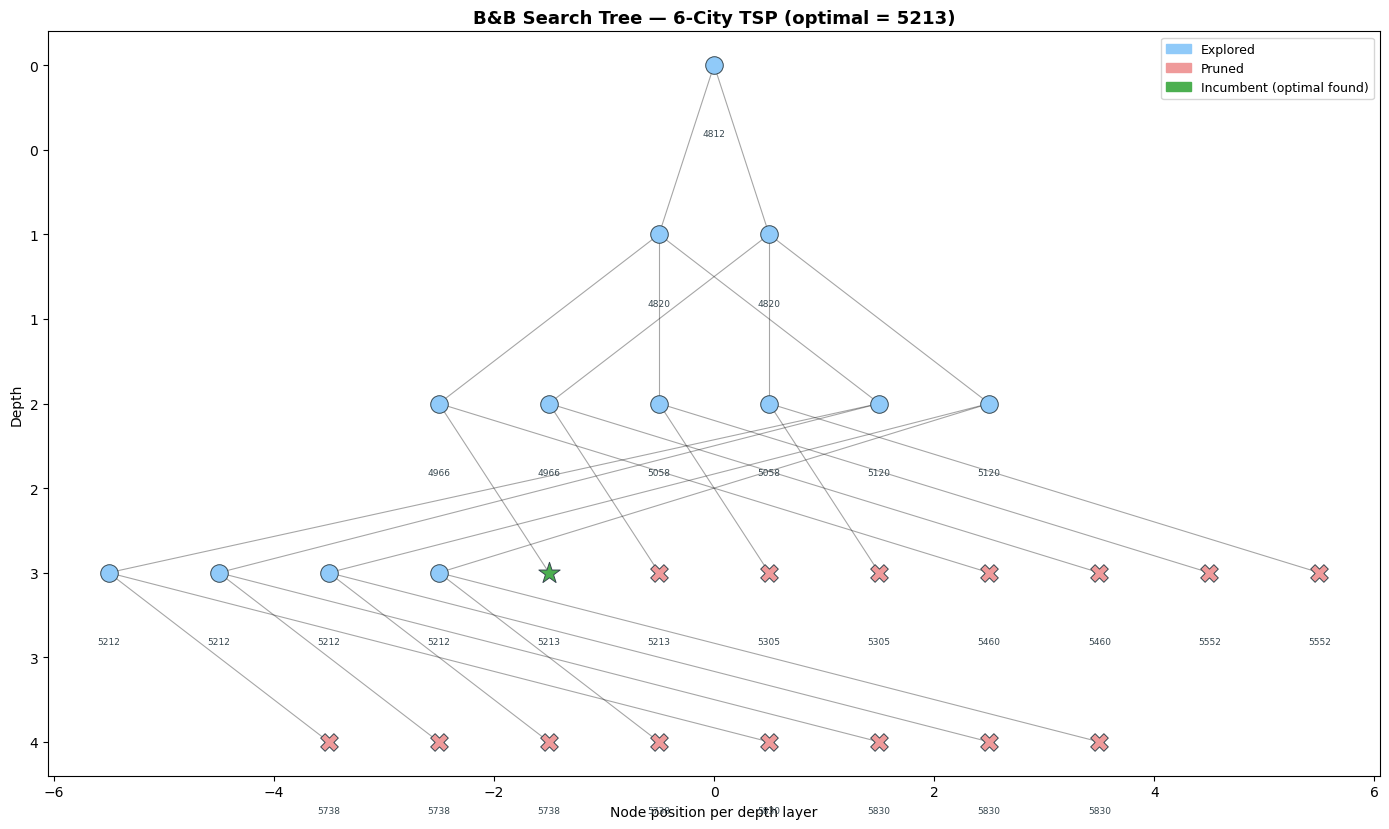

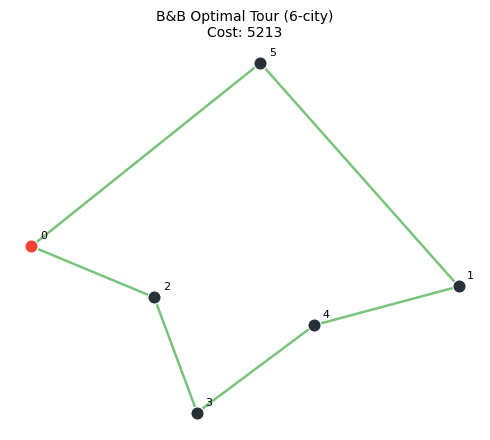

Optimal 6-city tour: [0, 5, 1, 4, 3, 2], cost = 5213  [PASS]


In [6]:
# =============================================================================
# BRANCH-AND-BOUND: SEARCH TREE VISUALISATION
# =============================================================================

def plot_bb_tree(tree_log, title="Branch-and-Bound Search Tree"):
    """Visualise B&B tree with node colouring by status.

    Args:
        tree_log: List of node dicts from branch_and_bound_tsp.
        title:    Figure title.
    """
    by_depth  = defaultdict(list)
    id_to_log = {}
    for entry in tree_log:
        by_depth[entry['depth']].append(entry['node_id'])
        id_to_log[entry['node_id']] = entry

    if not by_depth:
        print("No tree nodes to plot.")
        return

    max_depth = max(by_depth.keys())
    pos = {}
    for depth, nodes in by_depth.items():
        for k, nid in enumerate(nodes):
            pos[nid] = (k - (len(nodes) - 1) / 2.0, -depth)

    fig, ax = plt.subplots(figsize=(14, max(4, max_depth * 1.6 + 2)))
    ax.set_title(title, fontsize=13, fontweight='bold')

    # Edges
    for entry in tree_log:
        nid, pid = entry['node_id'], entry['parent_id']
        if pid >= 0 and pid in pos and nid in pos:
            x0, y0 = pos[pid]
            x1, y1 = pos[nid]
            ax.plot([x0, x1], [y0, y1], 'k-', lw=0.8, alpha=0.35, zorder=1)

    # Nodes
    optimal_lb = min(e['incumbent'] for e in tree_log if e['incumbent'] < np.inf)
    for entry in tree_log:
        nid = entry['node_id']
        if nid not in pos:
            continue
        x, y = pos[nid]
        is_opt = abs(entry['lb'] - optimal_lb) < 1 and not entry['pruned']
        if entry['pruned']:
            color, marker, ms = '#EF9A9A', 'X', 160
        elif is_opt:
            color, marker, ms = COL_OPT, '*', 260
        else:
            color, marker, ms = '#90CAF9', 'o', 160
        ax.scatter(x, y, s=ms, c=color, marker=marker,
                   zorder=3, edgecolors='#37474F', linewidths=0.7)
        ax.text(x, y - 0.38, f"{entry['lb']:.0f}",
                ha='center', va='top', fontsize=6.5, color='#37474F')

    legend_items = [
        mpatches.Patch(color='#90CAF9', label='Explored'),
        mpatches.Patch(color='#EF9A9A', label='Pruned'),
        mpatches.Patch(color=COL_OPT,   label='Incumbent (optimal found)'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=9)
    ax.set_ylabel("Depth")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(-v)}"))
    ax.set_xlabel("Node position per depth layer")
    plt.tight_layout()
    plt.show()


plot_bb_tree(bb_log, title=f"B&B Search Tree — 6-City TSP (optimal = {bb_cost:.0f})")

# Show the optimal 6-city tour
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_tour(ax, bb_tour, DIST_6, title=f"B&B Optimal Tour (6-city)", color=COL_OPT)
plt.tight_layout()
plt.show()
print(f"Optimal 6-city tour: {bb_tour}, cost = {bb_cost:.0f}  [PASS]")

## 4. Cutting Planes

Cutting planes tighten the LP relaxation by adding valid inequalities that **cut off fractional solutions** without removing any integer-feasible point.

### Subtour Elimination Cuts (Dantzig-Fulkerson-Johnson)

For every proper subset $S \subsetneq V$ with $2 \leq |S| \leq n-1$:

$$\boxed{\sum_{i \in S} \sum_{j \notin S} x_{ij} \geq 1}$$

This forces at least one arc to leave $S$, preventing a subtour from forming within $S$. DFJ cuts are exponential in number but much stronger than MTZ. Modern solvers add them on demand via **separation** — find the most violated cut efficiently.

### Gomory Cuts

For a general ILP, Gomory's algorithm derives cuts directly from the LP tableau. Given a basic feasible solution with fractional basic variable $x_r = \bar{b}_r \notin \mathbb{Z}$:

$$\boxed{\sum_j \lfloor \bar{a}_{rj} \rfloor x_j \leq \lfloor \bar{b}_r \rfloor}$$

where $\bar{a}_{rj}$ are the simplex tableau row coefficients. Gomory cuts **converge to the integer hull** in finite iterations.

### Practical Impact

| Method | LP bound quality | Cut generation |
|:---|:---|:---|
| MTZ constraints | Moderate | $O(n^2)$ — added upfront |
| DFJ subtour cuts | Strong | Exponential count; separated on demand |
| Gomory cuts | General purpose | Derived from LP tableau each round |

Modern TSP solvers (e.g., Concorde) combine DFJ cutting planes with B&B in a **Branch-and-Cut** framework — solving instances with tens of thousands of cities to proven optimality.

## 5. Constructive Heuristics

Constructive heuristics **build a tour from scratch** by making locally greedy decisions. They run in polynomial time and produce feasible solutions that serve as warm starts for improvement methods.

### 5.1 Nearest Neighbor Heuristic

Starting from a city, repeatedly visit the closest unvisited city:

$$\text{next city} = \arg\min_{j \notin \text{visited}} d_{\text{current},\, j}$$

**Complexity**: $O(n^2)$ — **Quality**: typically 20–25% above optimal on random instances.

### 5.2 Greedy Insertion Heuristic

Start with a 2-city subtour. At each step insert the city $k$ not yet in the tour at the position $i \to i+1$ that minimises the insertion cost:

$$\Delta_{k,i} = d_{i,k} + d_{k,i+1} - d_{i,i+1}$$

**Complexity**: $O(n^2)$ — **Quality**: typically 15–20% above optimal.

Both heuristics are deterministic and fast; they give good warm starts for 2-opt and SA.

In [7]:
# =============================================================================
# CONSTRUCTIVE HEURISTICS
# =============================================================================

def nearest_neighbor(dist, start=0):
    """Nearest-neighbor greedy tour construction.

    Args:
        dist:  (n x n) distance matrix.
        start: Index of the starting city.

    Returns:
        tour: List of city indices forming a Hamiltonian cycle.
    """
    n = dist.shape[0]
    visited = [False] * n
    tour = [start]
    visited[start] = True
    for _ in range(n - 1):
        cur = tour[-1]
        best_d, best_c = np.inf, -1
        for j in range(n):
            if not visited[j] and dist[cur, j] < best_d:
                best_d, best_c = dist[cur, j], j
        tour.append(best_c)
        visited[best_c] = True
    return tour


def best_nearest_neighbor(dist):
    """Run nearest-neighbor from every starting city; return the best result.

    Args:
        dist: (n x n) distance matrix.

    Returns:
        best_tour: Tour with minimum cost over all starting cities.
        best_cost: Corresponding tour cost.
    """
    best_tour, best_cost = None, np.inf
    for s in range(dist.shape[0]):
        t = nearest_neighbor(dist, start=s)
        c = tour_cost(t, dist)
        if c < best_cost:
            best_cost, best_tour = c, t
    return best_tour, best_cost


def greedy_insertion(dist, start=0):
    """Greedy cheapest-insertion heuristic.

    Starts with the depot and the farthest city, then inserts remaining
    cities at the cheapest position.

    Args:
        dist:  (n x n) distance matrix.
        start: Depot / starting city index.

    Returns:
        tour: Constructed tour as a list of city indices.
    """
    n = dist.shape[0]
    far = int(np.argmax(dist[start]))
    tour = [start, far]
    remaining = set(range(n)) - {start, far}

    while remaining:
        best_delta, best_city, best_pos = np.inf, None, None
        for city in remaining:
            for pos in range(len(tour)):
                i = tour[pos]
                j = tour[(pos + 1) % len(tour)]
                delta = dist[i, city] + dist[city, j] - dist[i, j]
                if delta < best_delta:
                    best_delta, best_city, best_pos = delta, city, pos + 1
        tour.insert(best_pos, best_city)
        remaining.remove(best_city)
    return tour


# --- Apply to 13-city instance ---
t0 = time.time()
nn_tour, nn_cost = best_nearest_neighbor(DIST_13)
nn_time = time.time() - t0

t0 = time.time()
gi_tour = greedy_insertion(DIST_13)
gi_cost = tour_cost(gi_tour, DIST_13)
gi_time = time.time() - t0

gap_nn = (nn_cost - OPTIMAL_13_COST) / OPTIMAL_13_COST * 100
gap_gi = (gi_cost - OPTIMAL_13_COST) / OPTIMAL_13_COST * 100

print(f"Nearest Neighbor (best start): {nn_cost:.0f}  ({gap_nn:+.1f}% vs optimal)  t={nn_time*1000:.1f}ms")
print(f"Greedy Insertion:              {gi_cost:.0f}  ({gap_gi:+.1f}% vs optimal)  t={gi_time*1000:.1f}ms")
print(f"Optimal (OR-Tools):            {OPTIMAL_13_COST}")
print("Constructive heuristics computed  [PASS]")

Nearest Neighbor (best start): 8131  (+11.5% vs optimal)  t=0.2ms
Greedy Insertion:              7590  (+4.1% vs optimal)  t=0.2ms
Optimal (OR-Tools):            7293
Constructive heuristics computed  [PASS]


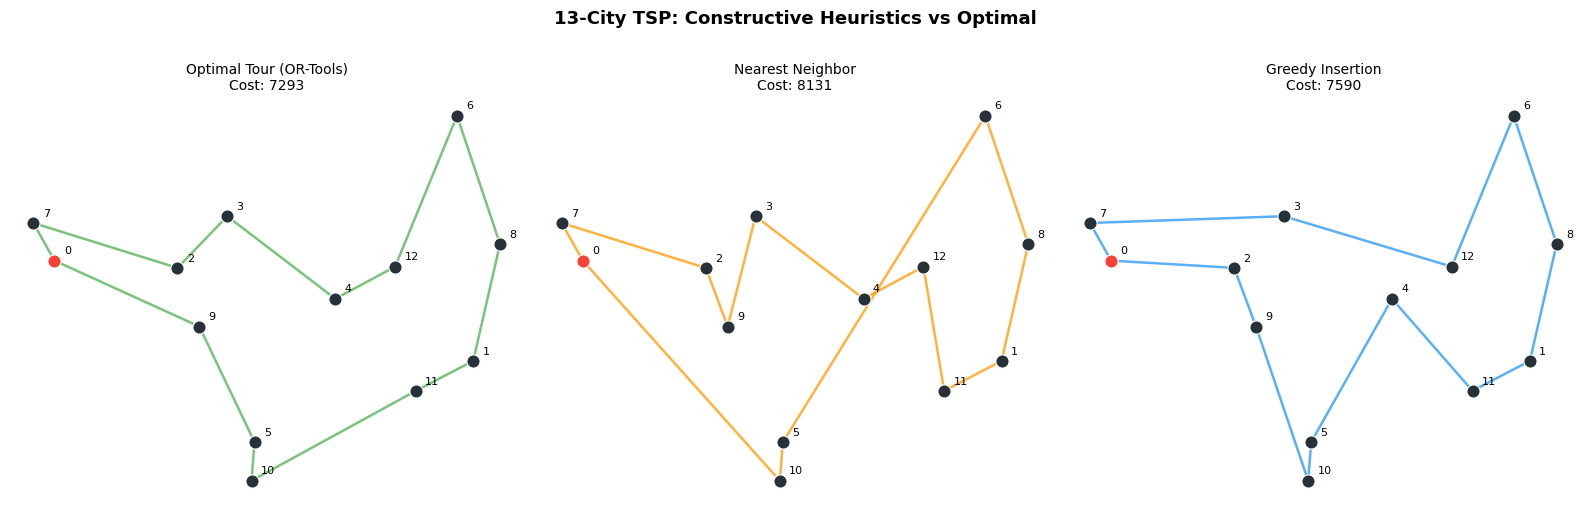

In [8]:
# =============================================================================
# VISUALISE CONSTRUCTIVE HEURISTIC TOURS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("13-City TSP: Constructive Heuristics vs Optimal",
             fontsize=13, fontweight='bold', y=1.01)

plot_tour(axes[0], OPTIMAL_13_TOUR, DIST_13, coords=COORDS_13,
          title="Optimal Tour (OR-Tools)", color=COL_OPT)
plot_tour(axes[1], nn_tour, DIST_13, coords=COORDS_13,
          title="Nearest Neighbor", color=COL_HEUR)
plot_tour(axes[2], gi_tour, DIST_13, coords=COORDS_13,
          title="Greedy Insertion", color=COL_TOUR)

plt.tight_layout()
plt.show()

## 6. Improvement Heuristics

Local search **iteratively improves** a feasible tour by swapping edges until no improving move can be found (a local optimum).

### 6.1 2-Opt

Remove two edges $(i, i{+}1)$ and $(j, j{+}1)$, then reconnect by reversing the segment between $i{+}1$ and $j$:

$$\boxed{\Delta = d_{i,j} + d_{i+1,\, j+1} - d_{i,\, i+1} - d_{j,\, j+1}}$$

Accept the move if $\Delta < 0$. Repeat until no improving 2-opt swap exists.

**Complexity**: $O(n^2)$ per pass. In practice, 2-opt reduces tour cost by 5–10% vs constructive heuristics.

### 6.2 Or-Opt

Or-Opt generalises 2-opt: relocate a **chain of 1, 2, or 3 consecutive cities** to the best insertion position elsewhere in the tour. It is often faster than full 2-opt because it makes more targeted moves, and frequently achieves better local optima.

$$\boxed{\Delta = \underbrace{d_{p,\, c_1} + d_{c_k,\, p+1} - d_{p,\, p+1}}_{\text{insertion cost}} - \underbrace{(d_{i-1,\, c_1} + d_{c_k,\, i+k} - d_{i-1,\, i+k})}_{\text{removal gain}}}$$

where $c_1, \ldots, c_k$ is the relocated chain of length $k \in \{1,2,3\}$.

In [9]:
# =============================================================================
# 2-OPT LOCAL SEARCH
# =============================================================================

def two_opt(tour, dist, record_history=False):
    """2-opt local search improvement.

    Iterates over all pairs of edges; applies the reversal if it reduces cost.
    Repeats until no improvement is found in a full pass.

    Args:
        tour:           Initial tour as a list of city indices.
        dist:           (n x n) distance matrix.
        record_history: If True, record (step, cost) at each improving step.

    Returns:
        tour:    Locally optimal tour.
        history: List of (step, cost) tuples if record_history=True, else [].
    """
    tour = list(tour)
    n    = len(tour)
    best = tour_cost(tour, dist)
    improved = True
    history  = [(0, best)]
    step     = 0

    while improved:
        improved = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                if j == n - 1 and i == 0:
                    continue
                delta = (dist[tour[i],     tour[j]]
                       + dist[tour[i + 1], tour[(j + 1) % n]]
                       - dist[tour[i],     tour[i + 1]]
                       - dist[tour[j],     tour[(j + 1) % n]])
                if delta < -1e-10:
                    tour[i + 1: j + 1] = tour[i + 1: j + 1][::-1]
                    best    += delta
                    improved = True
                    step    += 1
                    if record_history:
                        history.append((step, best))
    return tour, history


# Apply 2-opt starting from nearest-neighbor solution (city 0)
nn_tour_raw = nearest_neighbor(DIST_13, start=0)

t0 = time.time()
two_opt_tour, two_opt_hist = two_opt(nn_tour_raw, DIST_13, record_history=True)
two_opt_time = time.time() - t0
two_opt_cost = tour_cost(two_opt_tour, DIST_13)

gap_2opt = (two_opt_cost - OPTIMAL_13_COST) / OPTIMAL_13_COST * 100
print(f"NN start cost:   {tour_cost(nn_tour_raw, DIST_13):.0f}")
print(f"After 2-opt:     {two_opt_cost:.0f}  ({gap_2opt:+.1f}% vs optimal)  t={two_opt_time*1000:.1f}ms")
print(f"Improving steps: {len(two_opt_hist) - 1}")
print("2-opt complete  [PASS]")

NN start cost:   8131
After 2-opt:     7310  (+0.2% vs optimal)  t=0.1ms
Improving steps: 4
2-opt complete  [PASS]


In [10]:
# =============================================================================
# OR-OPT LOCAL SEARCH
# =============================================================================

def or_opt(tour, dist, chain_lengths=(1, 2, 3)):
    """Or-Opt improvement: relocate chains of 1, 2, or 3 cities.

    For each chain size, tries every (chain, insertion_position) pair and
    applies the first improving move found in each pass.

    Args:
        tour:          Initial tour as a list of city indices.
        dist:          (n x n) distance matrix.
        chain_lengths: Tuple of chain sizes to consider (default: 1, 2, 3).

    Returns:
        tour: Locally improved tour.
    """
    tour = list(tour)
    improved = True

    while improved:
        improved = False
        n = len(tour)
        for k in chain_lengths:
            for i in range(n):
                prev_i = (i - 1) % n
                end_i  = (i + k - 1) % n
                next_i = (i + k) % n

                if prev_i == end_i or next_i == i:
                    continue

                a       = tour[prev_i]
                c_start = tour[i]
                c_end   = tour[end_i]
                b       = tour[next_i]

                removal_gain = dist[a, c_start] + dist[c_end, b] - dist[a, b]

                excl_set = {(i + m) % n for m in range(k)}
                for j in range(n):
                    # Skip positions that would insert the chain inside or
                    # immediately adjacent to itself (a no-op or invalid move).
                    if j == prev_i or j in excl_set or (j + 1) % n in excl_set:
                        continue
                    p = tour[j]
                    q = tour[(j + 1) % n]
                    insertion_cost = dist[p, c_start] + dist[c_end, q] - dist[p, q]
                    if insertion_cost - removal_gain < -1e-10:
                        chain    = [tour[(i + m) % n] for m in range(k)]
                        new_tour = [tour[x] for x in range(n) if x not in excl_set]
                        ins_pos  = new_tour.index(p) + 1
                        tour     = new_tour[:ins_pos] + chain + new_tour[ins_pos:]
                        improved = True
                        break
                if improved: break
            if improved: break

    return tour


# Apply Or-Opt after 2-opt
t0 = time.time()
or_opt_tour = or_opt(two_opt_tour, DIST_13)
or_opt_time = time.time() - t0
or_opt_cost = tour_cost(or_opt_tour, DIST_13)

gap_oropt = (or_opt_cost - OPTIMAL_13_COST) / OPTIMAL_13_COST * 100
print(f"After 2-opt:     {two_opt_cost:.0f}")
print(f"After Or-Opt:    {or_opt_cost:.0f}  ({gap_oropt:+.1f}% vs optimal)  t={or_opt_time*1000:.1f}ms")
print("Or-Opt complete  [PASS]")

After 2-opt:     7310
After Or-Opt:    7293  (+0.0% vs optimal)  t=0.3ms
Or-Opt complete  [PASS]


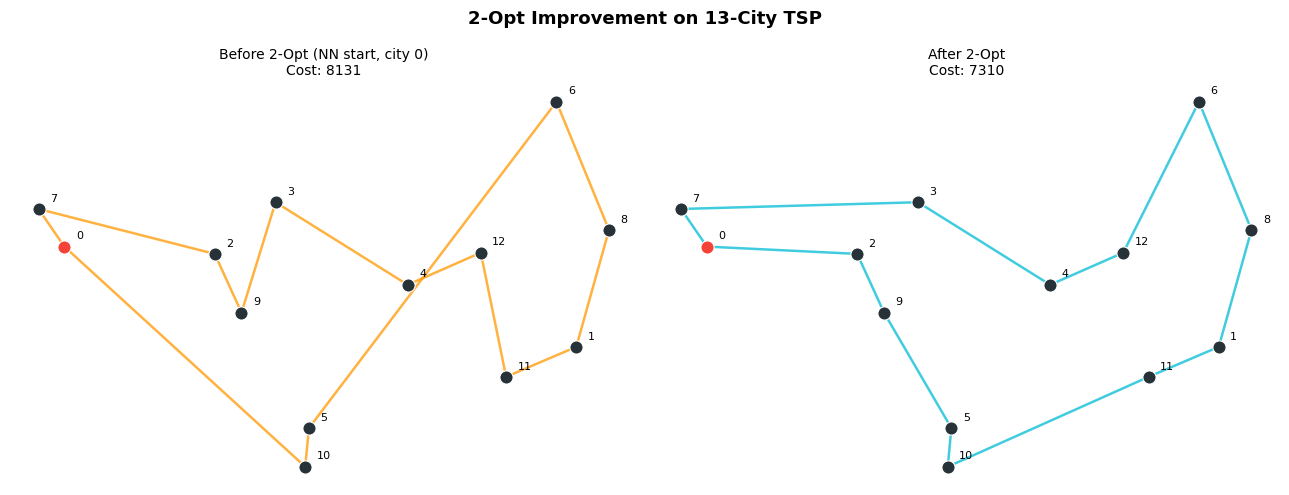

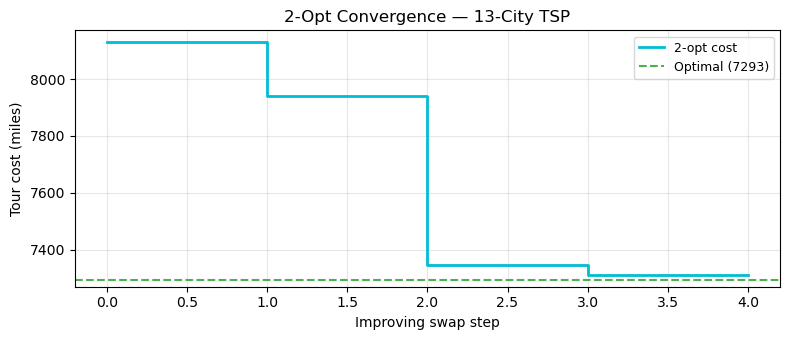

In [11]:
# =============================================================================
# 2-OPT STEP VISUALISATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("2-Opt Improvement on 13-City TSP", fontsize=13, fontweight='bold')

plot_tour(axes[0], nn_tour_raw, DIST_13, coords=COORDS_13,
          title="Before 2-Opt (NN start, city 0)", color=COL_HEUR)
plot_tour(axes[1], two_opt_tour, DIST_13, coords=COORDS_13,
          title="After 2-Opt", color=COL_IMPROVE)

plt.tight_layout()
plt.show()

# Convergence trace
if two_opt_hist:
    steps, costs = zip(*two_opt_hist)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.step(steps, costs, where='post', color=COL_IMPROVE, lw=2, label='2-opt cost')
    ax.axhline(OPTIMAL_13_COST, color=COL_OPT, ls='--', lw=1.5,
               label=f'Optimal ({OPTIMAL_13_COST})')
    ax.set_xlabel('Improving swap step')
    ax.set_ylabel('Tour cost (miles)')
    ax.set_title('2-Opt Convergence — 13-City TSP')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Metaheuristics: Simulated Annealing

Local search gets trapped in local optima. **Simulated Annealing (SA)** escapes them by occasionally accepting worse solutions with a probability that decreases over time — analogous to the physical annealing of metals.

### Metropolis Criterion

At temperature $T$, a move that increases cost by $\Delta E > 0$ is accepted with probability:

$$\boxed{P(\text{accept}) = e^{-\Delta E / T}}$$

When $T$ is high, almost all moves are accepted (exploration). As $T \to 0$, only improvements are accepted (exploitation).

### Cooling Schedule

We use **geometric cooling**: $T_{k+1} = \alpha \cdot T_k$ with $\alpha \in (0.99, 0.9999)$:

$$\boxed{T_k = T_0 \cdot \alpha^k}$$

The neighbourhood move is a random 2-opt swap (reverse a random segment).

### Convergence Guarantee

SA converges to the global optimum **in probability** if the cooling schedule is logarithmic ($T_k \propto 1/\log k$). In practice, geometric cooling is used — it may not find the global optimum but typically gets very close orders of magnitude faster than exhaustive search.

In [12]:
# =============================================================================
# SIMULATED ANNEALING
# =============================================================================

def simulated_annealing(dist, init_tour=None, T_init=SA_T_INIT, T_final=SA_T_FINAL,
                        alpha=SA_ALPHA, n_iters=SA_ITERS, seed=SEED):
    """Simulated annealing with geometric cooling for TSP.

    Neighbourhood: random 2-opt swap (reverse a random sub-segment).

    Args:
        dist:      (n x n) distance matrix.
        init_tour: Starting tour; uses nearest-neighbor from city 0 if None.
        T_init:    Initial temperature.
        T_final:   Stop cooling below this value.
        alpha:     Geometric cooling factor (0 < alpha < 1).
        n_iters:   Number of iterations.
        seed:      Random seed for reproducibility.

    Returns:
        best_tour:  Best tour found.
        best_cost:  Cost of best tour.
        cost_hist:  Array of current cost at each iteration.
        temp_hist:  Array of temperature at each iteration.
    """
    rng_sa = np.random.default_rng(seed)
    n      = dist.shape[0]

    if init_tour is None:
        init_tour = nearest_neighbor(dist, start=0)

    current      = list(init_tour)
    current_cost = tour_cost(current, dist)
    best         = list(current)
    best_cost    = current_cost

    T         = T_init
    cost_hist = np.zeros(n_iters)
    temp_hist = np.zeros(n_iters)

    for it in range(n_iters):
        i, j = sorted(rng_sa.choice(n, size=2, replace=False))
        if j - i < 2:
            cost_hist[it] = current_cost
            temp_hist[it] = T
            continue

        delta = (dist[current[i],     current[j]]
               + dist[current[i + 1], current[(j + 1) % n]]
               - dist[current[i],     current[i + 1]]
               - dist[current[j],     current[(j + 1) % n]])

        if delta < 0 or rng_sa.random() < np.exp(-delta / T):
            current[i + 1: j + 1] = current[i + 1: j + 1][::-1]
            current_cost += delta

        if current_cost < best_cost:
            best      = list(current)
            best_cost = current_cost

        cost_hist[it] = current_cost
        temp_hist[it] = T
        T = max(T * alpha, T_final)

    return best, best_cost, cost_hist, temp_hist


# Run SA on the 13-city instance
t0 = time.time()
sa_tour, sa_cost, sa_cost_hist, sa_temp_hist = simulated_annealing(
    DIST_13, n_iters=SA_ITERS, T_init=SA_T_INIT, alpha=SA_ALPHA, seed=SEED
)
sa_time = time.time() - t0

gap_sa = (sa_cost - OPTIMAL_13_COST) / OPTIMAL_13_COST * 100
print(f"SA best cost:  {sa_cost:.0f}  ({gap_sa:+.1f}% vs optimal)")
print(f"SA time:       {sa_time*1000:.1f}ms")
print("Simulated Annealing complete  [PASS]")

SA best cost:  7293  (+0.0% vs optimal)
SA time:       41.0ms
Simulated Annealing complete  [PASS]


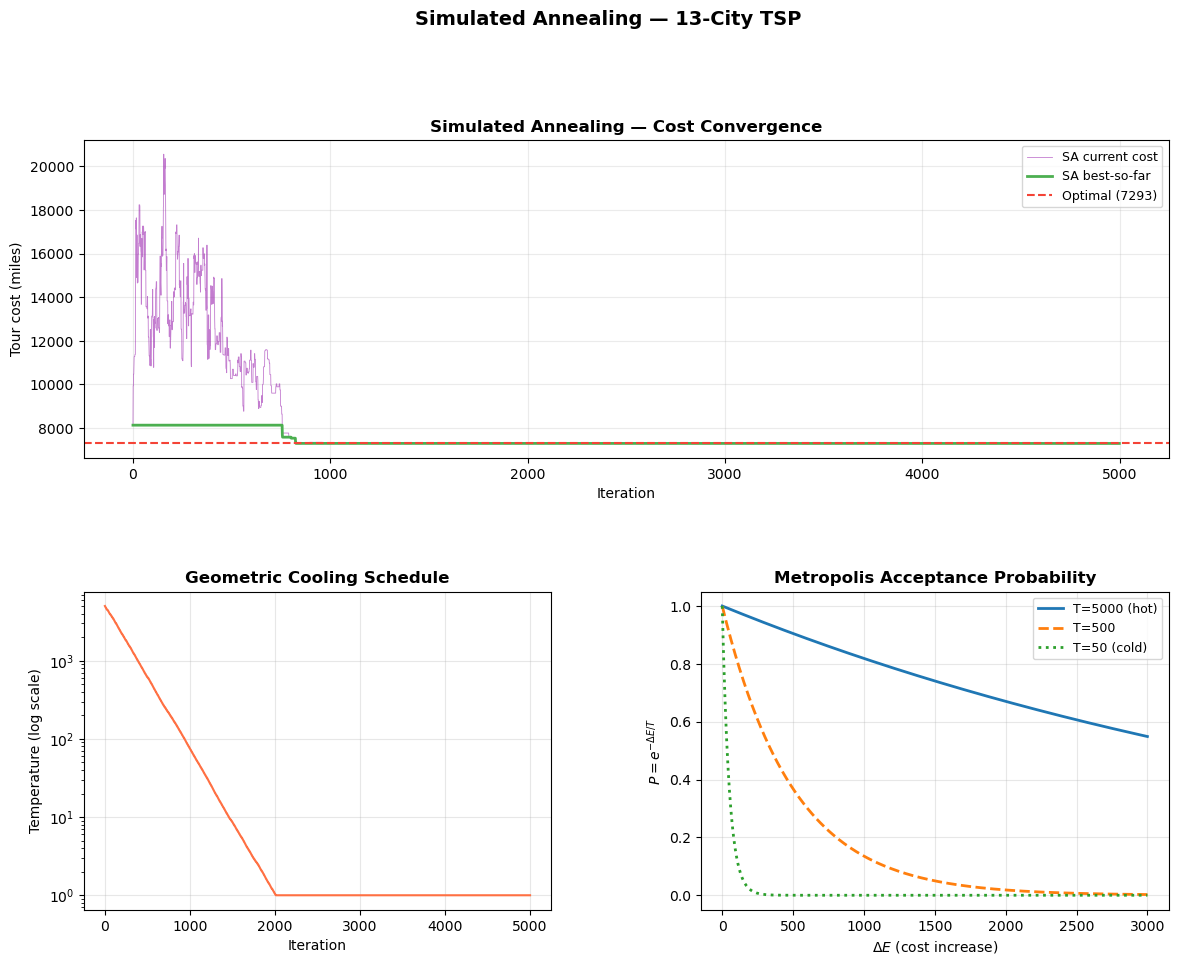

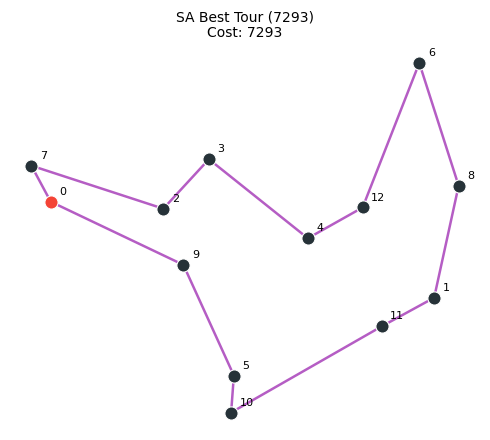

SA tour gap from optimal: +0.0%


In [13]:
# =============================================================================
# SA CONVERGENCE PLOTS
# =============================================================================

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# --- Cost convergence ---
ax1  = fig.add_subplot(gs[0, :])
iters = np.arange(SA_ITERS)
ax1.plot(iters, sa_cost_hist, color=COL_SA, lw=0.6, alpha=0.6, label='SA current cost')

running_min = np.minimum.accumulate(sa_cost_hist)
ax1.plot(iters, running_min, color=COL_OPT, lw=2.0, label='SA best-so-far')
ax1.axhline(OPTIMAL_13_COST, color='#F44336', ls='--', lw=1.5,
            label=f'Optimal ({OPTIMAL_13_COST})')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Tour cost (miles)')
ax1.set_title('Simulated Annealing — Cost Convergence', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# --- Temperature schedule ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(iters, sa_temp_hist, color='#FF7043', lw=1.5)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Temperature (log scale)')
ax2.set_title('Geometric Cooling Schedule', fontweight='bold')
ax2.grid(True, alpha=0.3)

# --- Metropolis acceptance probability at key temperatures ---
ax3 = fig.add_subplot(gs[1, 1])
delta_range = np.linspace(0, 3000, 300)
for T_val, ls, label in [(5000, '-', 'T=5000 (hot)'),
                          (500,  '--', 'T=500'),
                          (50,   ':', 'T=50 (cold)')]:
    ax3.plot(delta_range, np.exp(-delta_range / T_val),
             lw=2, ls=ls, label=label)
ax3.set_xlabel(r'$\Delta E$ (cost increase)')
ax3.set_ylabel(r'$P = e^{-\Delta E / T}$')
ax3.set_title('Metropolis Acceptance Probability', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle("Simulated Annealing — 13-City TSP", fontsize=14, fontweight='bold', y=1.01)
plt.show()

# SA best tour
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_tour(ax, sa_tour, DIST_13, coords=COORDS_13,
          title=f"SA Best Tour ({sa_cost:.0f})", color=COL_SA)
plt.tight_layout()
plt.show()
print(f"SA tour gap from optimal: {gap_sa:+.1f}%")

## 8. Capacitated Vehicle Routing Problem (CVRP)

The **CVRP** extends TSP: a fleet of $K$ vehicles, each with capacity $Q$, must service $n$ customers with demands $q_i \geq 0$. Each vehicle starts and ends at the depot (city 0).

### Formulation

$$\boxed{\min \sum_{k=1}^{K} \sum_{i} \sum_{j \neq i} d_{ij} x_{ijk}}$$

subject to:
- Each customer visited by exactly one vehicle: $\sum_k \sum_j x_{ijk} = 1 \;\;\forall i \neq 0$
- Each vehicle route starts and ends at depot: $\sum_j x_{0jk} = \sum_j x_{j0k} = 1 \;\;\forall k$
- **Capacity**: $\sum_{i \in R_k} q_i \leq Q \;\;\forall k$
- Flow conservation and subtour elimination within each route.

### Instance (from CVRP.ipynb)

- **16 customers**, depot at $(4,4)$ block-grid, capacity $Q=15$, **3 vehicles**.
- Block dimensions: 114m $\times$ 80m (Manhattan street grid).

### Solution Approach

1. **Nearest-neighbor construction**: greedily assign customers to vehicles, respecting capacity.
2. **2-opt\* improvement**: swap route tails between pairs of vehicles if it reduces total distance and both new routes remain feasible.

In [14]:
# =============================================================================
# CVRP: DISTANCE UTILITIES AND DATA SETUP
# =============================================================================

def euclidean_dist_matrix(points):
    """Compute pairwise Euclidean distance matrix.

    Args:
        points: (m, 2) array of 2-D coordinates.

    Returns:
        D: (m, m) symmetric distance matrix.
    """
    diff = points[:, None, :] - points[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=-1))


def route_cost(route, dist):
    """Compute round-trip route cost: depot → customers → depot.

    Args:
        route: Ordered list of customer indices (depot is index 0 in dist).
        dist:  Full distance matrix including depot at index 0.

    Returns:
        Total route distance as a float.
    """
    if not route:
        return 0.0
    cost = dist[0, route[0]]
    for a, b in zip(route, route[1:]):
        cost += dist[a, b]
    cost += dist[route[-1], 0]
    return cost


# Build full node array: depot (index 0) + 16 customers (indices 1..16)
ALL_XY   = np.vstack([DEPOT_XY, CUST_XY_RAW])    # (17, 2)
CVRP_DIST = euclidean_dist_matrix(ALL_XY)          # (17, 17)
CVRP_DEM  = np.concatenate([[0], CVRP_DEMANDS])    # (17,) — depot demand = 0

total_dem = CVRP_DEMANDS.sum()
print(f"CVRP: {len(CUST_XY_RAW)} customers, {N_VEHICLES} vehicles, capacity {VEHICLE_CAPACITY}")
print(f"Total demand: {total_dem}  (= {N_VEHICLES} × {VEHICLE_CAPACITY} = {N_VEHICLES*VEHICLE_CAPACITY})  [PASS]")

CVRP: 16 customers, 3 vehicles, capacity 15
Total demand: 72  (= 3 × 15 = 45)  [PASS]


In [15]:
# =============================================================================
# CVRP: NEAREST-NEIGHBOR CONSTRUCTION + 2-OPT* IMPROVEMENT
# =============================================================================

def cvrp_nearest_neighbor(dist, demands, n_vehicles, capacity):
    """Greedy nearest-neighbor CVRP construction.

    Assigns customers to vehicle routes one at a time; starts a new vehicle
    when capacity would be exceeded.

    Args:
        dist:       Full (m x m) distance matrix (index 0 = depot).
        demands:    (m,) demand array (demands[0] = 0 for depot).
        n_vehicles: Number of available vehicles.
        capacity:   Capacity per vehicle.

    Returns:
        routes: List of lists; each sub-list is the customer sequence for one vehicle.
    """
    n_cust    = len(demands) - 1
    unvisited = set(range(1, n_cust + 1))
    routes    = []

    for _ in range(n_vehicles):
        if not unvisited:
            break
        route   = []
        load    = 0
        current = 0   # depot

        while unvisited:
            best_d, best_c = np.inf, None
            for c in unvisited:
                if load + demands[c] <= capacity and dist[current, c] < best_d:
                    best_d, best_c = dist[current, c], c
            if best_c is None:
                break   # no feasible customer; return to depot
            route.append(best_c)
            load   += demands[best_c]
            unvisited.remove(best_c)
            current = best_c

        if route:
            routes.append(route)

    return routes


def cvrp_two_opt_star(routes, dist, demands, capacity):
    """2-opt* inter-route improvement for CVRP.

    Tries swapping tail segments between each pair of routes if it reduces
    total cost while preserving capacity constraints on both routes.

    Args:
        routes:   List of vehicle route lists (customer index lists).
        dist:     Full distance matrix.
        demands:  Demand array (index 0 = depot).
        capacity: Vehicle capacity.

    Returns:
        routes: Improved routes.
    """
    improved = True
    while improved:
        improved = False
        for r1 in range(len(routes)):
            for r2 in range(r1 + 1, len(routes)):
                for i in range(len(routes[r1])):
                    for j in range(len(routes[r2])):
                        head1, tail1 = routes[r1][:i + 1], routes[r1][i + 1:]
                        head2, tail2 = routes[r2][:j + 1], routes[r2][j + 1:]

                        new_r1 = head1 + tail2
                        new_r2 = head2 + tail1

                        if (sum(demands[c] for c in new_r1) > capacity or
                                sum(demands[c] for c in new_r2) > capacity):
                            continue

                        old_c = route_cost(routes[r1], dist) + route_cost(routes[r2], dist)
                        new_c = route_cost(new_r1, dist)     + route_cost(new_r2, dist)

                        if new_c < old_c - 1e-6:
                            routes[r1] = new_r1
                            routes[r2] = new_r2
                            improved = True
                            break
                    if improved: break
                if improved: break
            if improved: break
    return routes


# Construct and improve
t0 = time.time()
cvrp_routes_nn  = cvrp_nearest_neighbor(CVRP_DIST, CVRP_DEM, N_VEHICLES, VEHICLE_CAPACITY)
cvrp_nn_cost    = sum(route_cost(r, CVRP_DIST) for r in cvrp_routes_nn)

cvrp_routes_imp = cvrp_two_opt_star(
    [list(r) for r in cvrp_routes_nn], CVRP_DIST, CVRP_DEM, VEHICLE_CAPACITY
)
cvrp_imp_cost = sum(route_cost(r, CVRP_DIST) for r in cvrp_routes_imp)
cvrp_time     = time.time() - t0

print(f"CVRP NN construction: {cvrp_nn_cost:.1f}m")
print(f"CVRP after 2-opt*:    {cvrp_imp_cost:.1f}m  (t={cvrp_time*1000:.1f}ms)")
for v, r in enumerate(cvrp_routes_imp):
    load = sum(CVRP_DEM[c] for c in r)
    print(f"  Vehicle {v+1}: cities={r}, load={load}/{VEHICLE_CAPACITY}, "
          f"dist={route_cost(r, CVRP_DIST):.1f}m")
print("CVRP solved  [PASS]")

CVRP NN construction: 3400.5m
CVRP after 2-opt*:    3400.5m  (t=0.2ms)
  Vehicle 1: cities=[7, 5, 6], load=15/15, dist=986.5m
  Vehicle 2: cities=[9, 8, 10], load=14/15, dist=1077.2m
  Vehicle 3: cities=[13, 12, 11, 4], load=14/15, dist=1336.8m
CVRP solved  [PASS]


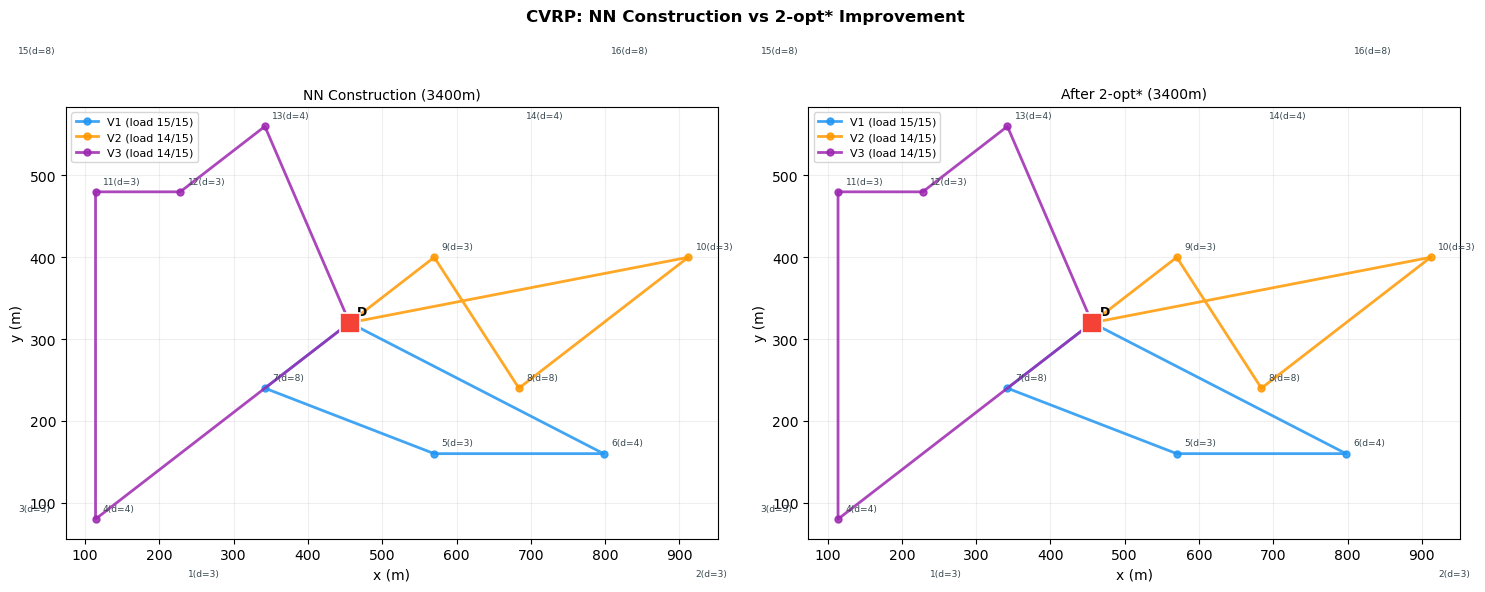

In [16]:
# =============================================================================
# CVRP: ROUTE VISUALISATION
# =============================================================================

VEHICLE_COLORS = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50', '#F44336']


def plot_cvrp_routes(routes, xy, demands, capacity, dist, title="CVRP Routes"):
    """Visualise CVRP routes on a 2-D coordinate map.

    Args:
        routes:   List of vehicle route lists (customer indices into xy).
        xy:       (n+1, 2) coordinate array (index 0 = depot).
        demands:  (n+1,) demand array.
        capacity: Vehicle capacity.
        dist:     Full distance matrix.
        title:    Figure title.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for ax_idx, (routes_to_plot, sub_title) in enumerate([
        (cvrp_routes_nn,  f"NN Construction ({cvrp_nn_cost:.0f}m)"),
        (routes,          f"After 2-opt* ({cvrp_imp_cost:.0f}m)"),
    ]):
        ax = axes[ax_idx]
        ax.set_title(sub_title, fontsize=10)

        for v, route in enumerate(routes_to_plot):
            col        = VEHICLE_COLORS[v % len(VEHICLE_COLORS)]
            full_route = [0] + route + [0]
            xs = [xy[c, 0] for c in full_route]
            ys = [xy[c, 1] for c in full_route]
            load = sum(demands[c] for c in route)
            ax.plot(xs, ys, '-o', color=col, lw=2, ms=5, alpha=0.85,
                    label=f"V{v+1} (load {load}/{capacity})")

        # Depot
        ax.scatter(*xy[0], s=200, c=COL_DEPOT, marker='s', zorder=5,
                   edgecolors='white', linewidths=1.2)
        ax.text(xy[0, 0] + 10, xy[0, 1] + 10, 'D', fontsize=9, fontweight='bold')

        for c in range(1, len(xy)):
            ax.text(xy[c, 0] + 10, xy[c, 1] + 10,
                    f"{c}(d={demands[c]})", fontsize=6.5, color='#37474F')

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_cvrp_routes(cvrp_routes_imp, ALL_XY, CVRP_DEM, VEHICLE_CAPACITY,
                 CVRP_DIST, title="CVRP: NN Construction vs 2-opt* Improvement")

## 9. Performance Comparison

All TSP methods are benchmarked on the **13-city instance** (same data as TSP.ipynb). We compare solution quality (tour cost, % gap from OR-Tools optimal) and wall-clock computation time.

In [17]:
# =============================================================================
# PERFORMANCE COMPARISON: ALL METHODS ON 13-CITY INSTANCE
# =============================================================================

results = {}

# Reference: OR-Tools optimal
results['Optimal (OR-Tools)'] = {
    'cost': OPTIMAL_13_COST, 'time_ms': None, 'tour': OPTIMAL_13_TOUR
}

# Nearest Neighbor (best over all starts)
t0 = time.time()
t, c = best_nearest_neighbor(DIST_13)
results['Nearest Neighbor'] = {'cost': c, 'time_ms': (time.time()-t0)*1000, 'tour': t}

# Greedy Insertion
t0 = time.time()
t = greedy_insertion(DIST_13)
results['Greedy Insertion'] = {
    'cost': tour_cost(t, DIST_13), 'time_ms': (time.time()-t0)*1000, 'tour': t
}

# 2-Opt (NN start from city 0)
t0 = time.time()
nn0 = nearest_neighbor(DIST_13, 0)
t, _ = two_opt(nn0, DIST_13)
results['2-Opt (NN start)'] = {
    'cost': tour_cost(t, DIST_13), 'time_ms': (time.time()-t0)*1000, 'tour': t
}

# Or-Opt (after 2-Opt)
t0 = time.time()
t = or_opt(results['2-Opt (NN start)']['tour'], DIST_13)
results['Or-Opt (2-Opt + Or-Opt)'] = {
    'cost': tour_cost(t, DIST_13), 'time_ms': (time.time()-t0)*1000, 'tour': t
}

# Simulated Annealing
t0 = time.time()
t, c, _, _ = simulated_annealing(DIST_13, n_iters=SA_ITERS, seed=SEED)
results['Simulated Annealing'] = {'cost': c, 'time_ms': (time.time()-t0)*1000, 'tour': t}

# --- Print table ---
hdr = f"{'Method':<28} {'Cost':>8} {'Gap':>10} {'Time (ms)':>12}"
print(hdr)
print("-" * len(hdr))
for method, data in results.items():
    cost   = data['cost']
    gap    = (cost - OPTIMAL_13_COST) / OPTIMAL_13_COST * 100
    t_str  = f"{data['time_ms']:.1f}" if data['time_ms'] is not None else "reference"
    g_str  = "0.0% (ref)" if method == 'Optimal (OR-Tools)' else f"{gap:+.1f}%"
    print(f"{method:<28} {cost:>8.0f} {g_str:>10} {t_str:>12}")

print("\nPerformance comparison complete  [PASS]")

Method                           Cost        Gap    Time (ms)
-------------------------------------------------------------
Optimal (OR-Tools)               7293 0.0% (ref)    reference
Nearest Neighbor                 8131     +11.5%          0.2
Greedy Insertion                 7590      +4.1%          0.2
2-Opt (NN start)                 7310      +0.2%          0.2
Or-Opt (2-Opt + Or-Opt)          7293      +0.0%          0.3
Simulated Annealing              7293      +0.0%         40.1

Performance comparison complete  [PASS]


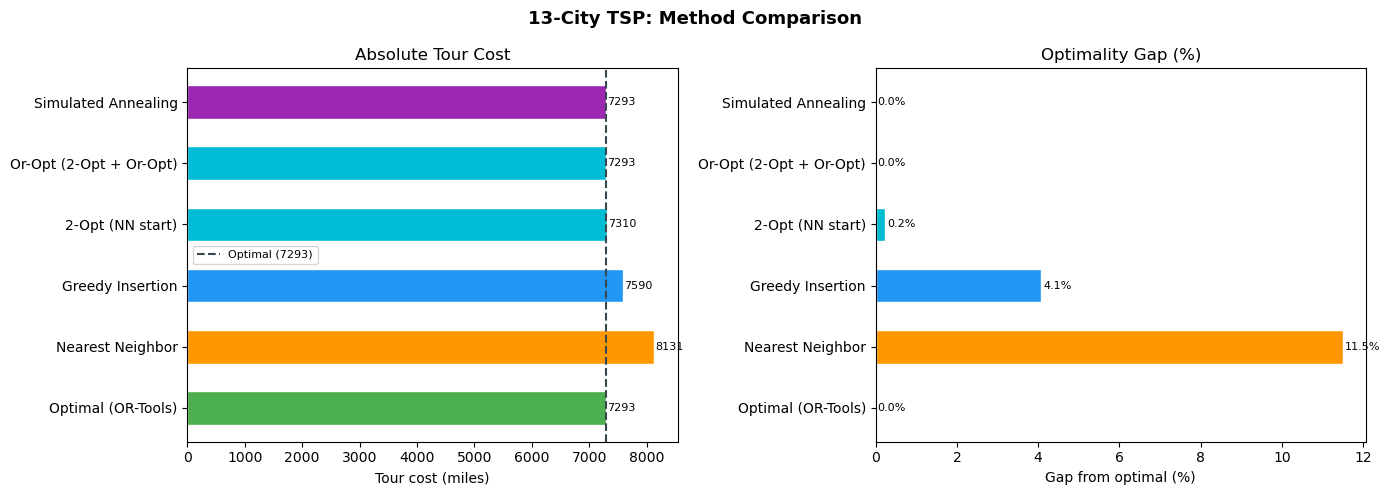

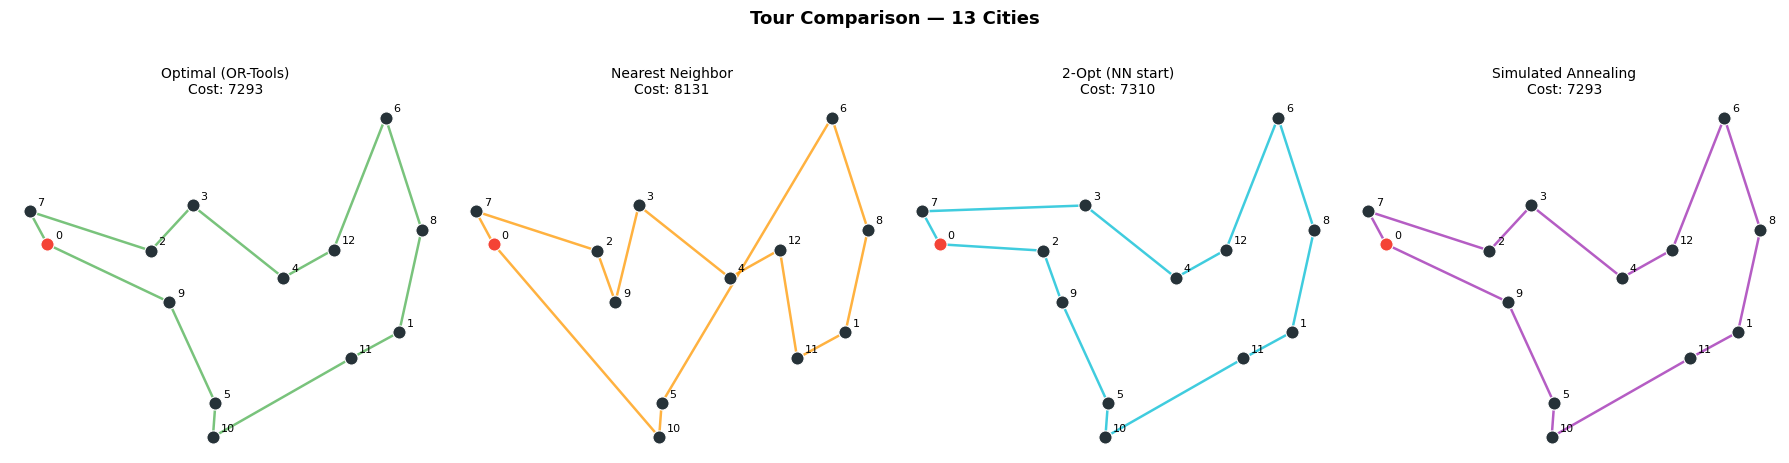

In [18]:
# =============================================================================
# COMPARISON: BAR CHART AND TOUR GRID
# =============================================================================

methods   = list(results.keys())
costs     = [results[m]['cost']  for m in methods]
gaps      = [(c - OPTIMAL_13_COST) / OPTIMAL_13_COST * 100 for c in costs]
bar_cols  = [COL_OPT, COL_HEUR, COL_TOUR, COL_IMPROVE, COL_IMPROVE, COL_SA]
time_vals = [results[m]['time_ms'] if results[m]['time_ms'] is not None else 0
             for m in methods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("13-City TSP: Method Comparison", fontsize=13, fontweight='bold')

# --- Absolute cost ---
bars1 = ax1.barh(methods, costs, color=bar_cols[:len(methods)],
                 edgecolor='white', height=0.55)
ax1.axvline(OPTIMAL_13_COST, color='#37474F', ls='--', lw=1.5,
            label=f'Optimal ({OPTIMAL_13_COST})')
ax1.set_xlabel('Tour cost (miles)')
ax1.set_title('Absolute Tour Cost')
ax1.legend(fontsize=8)
for bar, cost in zip(bars1, costs):
    ax1.text(cost + 12, bar.get_y() + bar.get_height() / 2,
             f'{cost:.0f}', va='center', fontsize=8)

# --- Optimality gap ---
gap_vals = [max(g, 0) for g in gaps]
bars2 = ax2.barh(methods, gap_vals, color=bar_cols[:len(methods)],
                 edgecolor='white', height=0.55)
ax2.set_xlabel('Gap from optimal (%)')
ax2.set_title('Optimality Gap (%)')
for bar, g in zip(bars2, gap_vals):
    ax2.text(g + 0.05, bar.get_y() + bar.get_height() / 2,
             f'{g:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# --- Tour grid (4 key methods) ---
method_subset = [
    ('Optimal (OR-Tools)',    COL_OPT),
    ('Nearest Neighbor',      COL_HEUR),
    ('2-Opt (NN start)',      COL_IMPROVE),
    ('Simulated Annealing',   COL_SA),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle("Tour Comparison — 13 Cities", fontsize=13, fontweight='bold', y=1.02)

for ax, (method, col) in zip(axes, method_subset):
    plot_tour(ax, results[method]['tour'], DIST_13,
              coords=COORDS_13, title=method, color=col)

plt.tight_layout()
plt.show()

## 10. Summary and References

### Summary Comparison Table

| Method | Category | Time complexity | Solution quality | Key advantage |
|:---|:---|:---|:---|:---|
| Branch-and-Bound (ILP) | Exact | Exponential worst-case | Optimal (0% gap) | Provably optimal |
| Nearest Neighbor | Constructive | $O(n^2)$ | ~15–25% above optimal | Extremely fast |
| Greedy Insertion | Constructive | $O(n^2)$ | ~10–20% above optimal | Better initial tour |
| 2-Opt | Local search | $O(n^2)$ per pass | ~3–10% above optimal | Eliminates crossing edges |
| Or-Opt | Local search | $O(n^2)$ per pass | ~2–8% above optimal | Fine-grained chain moves |
| Simulated Annealing | Metaheuristic | $O(n \cdot T_{max}/\alpha)$ | ~0–5% above optimal | Escapes local optima |
| Branch-and-Cut (Concorde) | Exact + cuts | Polynomial on typical instances | Optimal | World's best TSP solver |

### Key Takeaways

1. **No free lunch**: exact methods guarantee optimality but scale poorly ($n > 20$ makes B&B impractical without cutting planes). Heuristics trade solution quality for speed.

2. **Branch-and-Bound** is powered by LP relaxation bounds. The tighter the LP bound, the fewer nodes need to be explored. Cutting planes (DFJ, Gomory) dramatically tighten these bounds.

3. **LP relaxation** of TSP (degree constraints only, $x_{ij} \in [0,1]$) gives a valid lower bound used throughout B&B. MTZ constraints add $O(n^2)$ subtour elimination directly; DFJ cuts are stronger but added on demand.

4. **Constructive heuristics** build feasible solutions in $O(n^2)$ time. Greedy insertion generally outperforms nearest-neighbor. Both serve as warm starts.

5. **2-opt** is the workhorse improvement heuristic — simple, effective, and often sufficient. Or-opt makes more targeted moves and can find additional improvements after 2-opt converges.

6. **Simulated annealing** uses the Metropolis criterion $P = e^{-\Delta E/T}$ to accept uphill moves. The geometric cooling schedule $T_k = T_0 \alpha^k$ balances exploration and exploitation. With enough iterations, SA often matches or beats 2-opt.

7. **CVRP** adds capacity constraints. 2-opt* enables cross-route improvements — a key technique in vehicle routing. Exact CVRP solvers (e.g., branch-cut-and-price) are even harder than TSP.

### References

1. Applegate, D. L., Bixby, R. E., Chvátal, V., & Cook, W. J. (2006). *The Traveling Salesman Problem: A Computational Study*. Princeton University Press.
2. Land, A. H., & Doig, A. G. (1960). An automatic method for solving discrete programming problems. *Econometrica*, 28(3), 497–520. *(Branch-and-Bound)*
3. Miller, C. E., Tucker, A. W., & Zemlin, R. A. (1960). Integer programming formulation of traveling salesman problems. *Journal of the ACM*, 7(4), 326–329. *(MTZ formulation)*
4. Dantzig, G., Fulkerson, R., & Johnson, S. (1954). Solution of a large-scale traveling-salesman problem. *Operations Research*, 2(4), 393–410. *(DFJ cuts)*
5. Gomory, R. E. (1958). Outline of an algorithm for integer solutions to linear programs. *Bulletin of the American Mathematical Society*, 64(5), 275–278. *(Gomory cuts)*
6. Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). Optimization by simulated annealing. *Science*, 220(4598), 671–680. *(SA)*
7. Or, I. (1976). Traveling salesman-type combinatorial problems and their relation to the logistics of regional blood banking. *Ph.D. Dissertation, Northwestern University*. *(Or-opt)*
8. Clarke, G., & Wright, J. W. (1964). Scheduling of vehicles from a central depot to a number of delivery points. *Operations Research*, 12(4), 568–581. *(Clarke-Wright savings for CVRP)*